# 01. Data Cleaning, Processing, and EDA

Candidate Number: VSXB6

This notebook performs the first stage of the coursework workflow:

- load the Conjura marketing mix dataset
- inspect structure and data quality
- clean and process fields for modelling
- run exploratory data analysis on the target and key drivers
- identify modelling risks such as missingness, leakage, and time dependence


## Workflow in this notebook (01 only)

1. **Data loading**: load the dataset and data dictionary.
2. **Data quality audit**: inspect schema, missingness, duplicates, and date coverage.
3. **Data cleaning and preprocessing**: standardise types, handle structural missingness, and create core derived fields.
4. **Exploratory analysis**: analyse target distribution, trends, relationships, and segment-level patterns.
5. **Risk review**: document leakage risks, outliers, and modelling caveats found in EDA.
6. **Handoff output**: save a cleaned working dataset for notebook 02 modelling.


## 1. Setup

In [2]:
# Import sys so we can update Python's module search path.
import sys
# Import Path for robust file and folder handling.
from pathlib import Path

# Import numpy for numerical operations.
import numpy as np
# Import pandas for data loading and manipulation.
import pandas as pd
# Import seaborn for statistical visualisation.
import seaborn as sns
# Import matplotlib for plotting control.
import matplotlib.pyplot as plt

# Detect the project root so imports work from either the project root or the notebooks folder.
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
# Check whether the project root is already available to Python.
if str(PROJECT_ROOT) not in sys.path:
    # Add the project root so the local src package can be imported.
    sys.path.insert(0, str(PROJECT_ROOT))

# Import shared configuration values such as file paths and target names.
from src.config import RAW_DATA_PATH, DATA_DICTIONARY_PATH, DATE_COLUMN, PRIMARY_TARGET, SECONDARY_TARGET

# Apply a clean default plotting style.
sns.set_theme(style="whitegrid")
# Show more columns when displaying DataFrames.
pd.set_option("display.max_columns", 100)
# Format floating-point values for easier reading.
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# Print the resolved project root to confirm the notebook environment.
# Print the path to the raw CSV file.
# Print the path to the data dictionary file.

# Print generic setup confirmation without exposing absolute local paths.
print("Project configuration loaded.")
print("Raw dataset and data dictionary paths are configured.")


Project root: C:\Users\cindy\Documents\Cindy\UCL Modules\Term 2 Modules\Predictive Analytics\Individual Assignment
Raw data path: C:\Users\cindy\Documents\Cindy\UCL Modules\Term 2 Modules\Predictive Analytics\Individual Assignment\dataset\conjura_mmm_data.csv
Data dictionary path: C:\Users\cindy\Documents\Cindy\UCL Modules\Term 2 Modules\Predictive Analytics\Individual Assignment\dataset\conjura_mmm_data_dictionary.xlsx


## 2. Load data

In [3]:
# Load the main dataset from the configured CSV path.
df = pd.read_csv(RAW_DATA_PATH)
# Load the data dictionary from the Excel file.
dictionary_df = pd.read_excel(DATA_DICTIONARY_PATH)

# Print the dataset shape as rows and columns.
print(df.shape)
# Show the first few rows of the raw dataset.
df.head()

(132759, 50)


,MMM_TIMESERIES_ID,ORGANISATION_ID,ORGANISATION_VERTICAL,ORGANISATION_SUBVERTICAL,ORGANISATION_MARKETING_SOURCES,ORGANISATION_PRIMARY_TERRITORY_NAME,TERRITORY_NAME,DATE_DAY,CURRENCY_CODE,FIRST_PURCHASES,FIRST_PURCHASES_UNITS,FIRST_PURCHASES_ORIGINAL_PRICE,FIRST_PURCHASES_GROSS_DISCOUNT,ALL_PURCHASES,ALL_PURCHASES_UNITS,ALL_PURCHASES_ORIGINAL_PRICE,ALL_PURCHASES_GROSS_DISCOUNT,GOOGLE_PAID_SEARCH_SPEND,GOOGLE_SHOPPING_SPEND,GOOGLE_PMAX_SPEND,GOOGLE_DISPLAY_SPEND,GOOGLE_VIDEO_SPEND,META_FACEBOOK_SPEND,META_INSTAGRAM_SPEND,META_OTHER_SPEND,TIKTOK_SPEND,GOOGLE_PAID_SEARCH_CLICKS,GOOGLE_SHOPPING_CLICKS,GOOGLE_PMAX_CLICKS,GOOGLE_DISPLAY_CLICKS,GOOGLE_VIDEO_CLICKS,META_FACEBOOK_CLICKS,META_INSTAGRAM_CLICKS,META_OTHER_CLICKS,TIKTOK_CLICKS,GOOGLE_PAID_SEARCH_IMPRESSIONS,GOOGLE_SHOPPING_IMPRESSIONS,GOOGLE_PMAX_IMPRESSIONS,GOOGLE_DISPLAY_IMPRESSIONS,GOOGLE_VIDEO_IMPRESSIONS,META_FACEBOOK_IMPRESSIONS,META_INSTAGRAM_IMPRESSIONS,META_OTHER_IMPRESSIONS,TIKTOK_IMPRESSIONS,DIRECT_CLICKS,BRANDED_SEARCH_CLICKS,ORGANIC_SEARCH_CLICKS,EMAIL_CLICKS,REFERRAL_CLICKS,ALL_OTHER_CLICKS
0,596eef7c71f933d820d0e485935d0e8f,04769dac8b828ec7a85676d9e2bffe6f,Beauty & Fitness,Hair Care,"Google, Meta",US,All Territories,2022-07-29,USD,22,27,"3,837.98",632.60,27,32,"4,552.98",846.59,NaN,NaN,205.53,NaN,NaN,233.75,NaN,NaN,NaN,NaN,NaN,255.00,NaN,NaN,163.00,NaN,NaN,NaN,NaN,NaN,"31,907.00",NaN,NaN,"18,997.00",NaN,NaN,NaN,139.00,NaN,300.00,1.00,61.00,40.00
1,596eef7c71f933d820d0e485935d0e8f,04769dac8b828ec7a85676d9e2bffe6f,Beauty & Fitness,Hair Care,"Google, Meta",US,All Territories,2022-07-30,USD,14,21,"2,748.00",444.00,17,26,"3,178.00",613.81,NaN,NaN,277.08,NaN,NaN,248.84,NaN,NaN,NaN,NaN,NaN,348.00,NaN,NaN,128.00,NaN,NaN,NaN,NaN,NaN,"44,483.00",NaN,NaN,"20,188.00",NaN,NaN,NaN,209.00,NaN,442.00,8.00,110.00,62.00
2,596eef7c71f933d820d0e485935d0e8f,04769dac8b828ec7a85676d9e2bffe6f,Beauty & Fitness,Hair Care,"Google, Meta",US,All Territories,2022-07-31,USD,31,39,"4,568.00","1,185.20",39,48,"5,469.00","1,505.00",NaN,NaN,427.44,NaN,NaN,274.51,NaN,NaN,NaN,NaN,NaN,405.00,NaN,NaN,148.00,NaN,NaN,NaN,NaN,NaN,"58,173.00",NaN,NaN,"24,718.00",NaN,NaN,NaN,262.00,NaN,427.00,631.00,108.00,65.00
3,596eef7c71f933d820d0e485935d0e8f,04769dac8b828ec7a85676d9e2bffe6f,Beauty & Fitness,Hair Care,"Google, Meta",US,All Territories,2022-08-01,USD,18,30,"2,878.98",696.52,22,34,"3,335.97",754.41,35.24,NaN,347.23,NaN,NaN,270.06,NaN,NaN,NaN,48.00,NaN,320.00,NaN,NaN,163.00,NaN,NaN,NaN,890.00,NaN,"55,559.00",NaN,NaN,"25,076.00",NaN,NaN,NaN,247.00,NaN,400.00,117.00,125.00,68.00
4,596eef7c71f933d820d0e485935d0e8f,04769dac8b828ec7a85676d9e2bffe6f,Beauty & Fitness,Hair Care,"Google, Meta",US,All Territories,2022-08-02,USD,23,27,"3,107.99",627.10,28,33,"3,991.99",934.01,38.40,NaN,314.95,NaN,NaN,257.62,NaN,NaN,NaN,46.00,NaN,330.00,NaN,NaN,127.00,NaN,NaN,NaN,702.00,NaN,"47,854.00",NaN,NaN,"22,688.00",NaN,NaN,NaN,255.00,NaN,425.00,37.00,146.00,65.00


In [4]:
# Show the first 15 rows of the data dictionary.
dictionary_df.head(15)

,Field,Definition,Notes
0,mmm_timeseries_id,unique identifier for a single MMM timeseries.,if aggregating accross multiple timeseries IDs...
1,organisation_id,"unique, anonymous identifier for an eCommerce ...",NaN
2,organisation_vertical,the top-level category of the highest selling ...,categorisation follows Google's eCommerce taxo...
3,organisation_subvertical,the sub-category of the highest selling products,""""""
4,organisation_marketing_sources,"at least one of Google, Meta, and/or Tiktok",spend from listed sources may not be present i...
5,organisation_primary_territory_name,the organisation's territory with the highest ...,NaN
6,territory_name,"values include mult-country ""All Territories"" ...","some orgs will have multiple territory spits, ..."
7,currency_code,currency for monetary fields,"when territory_name = ""all territories"" we use..."
8,date_day,observation date,each timeseries has a minimum of 449 sequentia...
9,first_purchases,"number of web purchases for new customers, i.e...",NaN


### Table interpretation

- The first rows confirm this file defines variables, business meaning, and caveats.
- Discount-related notes indicate possible leakage risk if used as predictors.
- It clarifies that this is panel/time-series style marketing data, not simple i.i.d. rows.


## 3. Standardise types and basic structure

In [5]:
# Remove extra whitespace from each column name.
df.columns = [col.strip() for col in df.columns]
# Convert the date column to pandas datetime format.
df[DATE_COLUMN] = pd.to_datetime(df[DATE_COLUMN])
# Sort the data by time series and date, then reset the index.
df = df.sort_values(["MMM_TIMESERIES_ID", DATE_COLUMN]).reset_index(drop=True)

# Collect all object-type columns, which are usually categorical variables.
categorical_cols = df.select_dtypes(include="object").columns.tolist()
# Collect all numeric columns for later analysis.
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

# Print the number of categorical columns.
print("categorical columns:", len(categorical_cols))
# Print the number of numeric columns.
print("numeric columns:", len(numeric_cols))
# Display the data types of the first 15 columns.
df.dtypes.head(15)

categorical columns: 8
numeric columns: 41


MMM_TIMESERIES_ID                              object
ORGANISATION_ID                                object
ORGANISATION_VERTICAL                          object
ORGANISATION_SUBVERTICAL                       object
ORGANISATION_MARKETING_SOURCES                 object
ORGANISATION_PRIMARY_TERRITORY_NAME            object
TERRITORY_NAME                                 object
DATE_DAY                               datetime64[ns]
CURRENCY_CODE                                  object
FIRST_PURCHASES                                 int64
FIRST_PURCHASES_UNITS                           int64
FIRST_PURCHASES_ORIGINAL_PRICE                float64
FIRST_PURCHASES_GROSS_DISCOUNT                float64
ALL_PURCHASES                                   int64
ALL_PURCHASES_UNITS                             int64
dtype: object

## 4. Initial data audit

In [6]:
# Build a small summary dictionary describing the dataset.
summary = {
    # Count the number of rows in the dataset.
    "rows": len(df),
    # Count the number of columns in the dataset.
    "columns": df.shape[1],
    # Find the earliest date in the data.
    "date_min": df[DATE_COLUMN].min(),
    # Find the latest date in the data.
    "date_max": df[DATE_COLUMN].max(),
    # Count unique time-series identifiers.
    "timeseries_ids": df["MMM_TIMESERIES_ID"].nunique(),
    # Count unique organisations.
    "organisations": df["ORGANISATION_ID"].nunique(),
    # Count unique territories.
    "territories": df["TERRITORY_NAME"].nunique(),
}
# Convert the summary dictionary into a display-friendly pandas Series.
pd.Series(summary)

rows                           132759
columns                            50
date_min          2019-07-21 00:00:00
date_max          2024-06-02 00:00:00
timeseries_ids                    143
organisations                      93
territories                        19
dtype: object

In [7]:
# Count exact duplicate rows across all columns.
duplicate_rows = df.duplicated().sum()
# Count duplicate records using the time-series ID and date as a key.
duplicate_keys = df.duplicated(subset=["MMM_TIMESERIES_ID", DATE_COLUMN]).sum()

# Print the number of exact duplicate rows.
print(f"Exact duplicate rows: {duplicate_rows}")
# Print the number of duplicated time-series/date combinations.
print(f"Duplicate time-series/date keys: {duplicate_keys}")

Exact duplicate rows: 0
Duplicate time-series/date keys: 0


In [8]:
# Compute the missing-value rate for each column.
missing_summary = (
    # Mark missing values as True.
    df.isna()
    # Convert the boolean mask into missing-value proportions.
    .mean()
    # Sort columns from the highest missing rate to the lowest.
    .sort_values(ascending=False)
    # Rename the resulting Series for clarity.
    .rename("missing_rate")
    # Convert the Series to a one-column DataFrame.
    .to_frame()
)
# Display the 20 columns with the most missing values.
missing_summary.head(20)

,missing_rate
TIKTOK_CLICKS,0.97
TIKTOK_SPEND,0.97
TIKTOK_IMPRESSIONS,0.97
GOOGLE_VIDEO_SPEND,0.94
GOOGLE_VIDEO_IMPRESSIONS,0.94
GOOGLE_VIDEO_CLICKS,0.94
GOOGLE_DISPLAY_SPEND,0.86
GOOGLE_DISPLAY_CLICKS,0.86
GOOGLE_DISPLAY_IMPRESSIONS,0.86
META_OTHER_CLICKS,0.82


### Table interpretation

- Missingness is concentrated in channel-specific media fields.
- This pattern is consistent with structural channel inactivity rather than random missing data.
- It supports explicit missing-value handling before modelling.


The dataset is structurally wide and sparse because not every brand or territory uses every channel. Missing paid-media fields are likely to mean channel inactivity rather than data corruption, but this should be treated carefully during modelling.

## 5. Clean and process modelling fields

In [9]:
# Find all columns that represent advertising spend.
spend_cols = [col for col in df.columns if col.endswith("_SPEND")]
# Find all columns that represent clicks.
click_cols = [col for col in df.columns if col.endswith("_CLICKS")]
# Find all columns that represent impressions.
impression_cols = [col for col in df.columns if col.endswith("_IMPRESSIONS")]

# Combine all media-related columns into one list.
media_cols = spend_cols + click_cols + impression_cols
# Define the non-paid traffic click columns explicitly.
non_paid_click_cols = [
    # Direct website traffic clicks.
    "DIRECT_CLICKS",
    # Branded search traffic clicks.
    "BRANDED_SEARCH_CLICKS",
    # Organic search traffic clicks.
    "ORGANIC_SEARCH_CLICKS",
    # Email campaign traffic clicks.
    "EMAIL_CLICKS",
    # Referral traffic clicks.
    "REFERRAL_CLICKS",
    # Other remaining click traffic.
    "ALL_OTHER_CLICKS",
]

# Identify fields that may leak information from the outcome into the model.
leakage_prone_cols = [
    # Discount values for first purchases may only be known after conversion.
    "FIRST_PURCHASES_GROSS_DISCOUNT",
    # Discount values for all purchases may also be post-outcome information.
    "ALL_PURCHASES_GROSS_DISCOUNT",
]

# Create a working copy so the original raw DataFrame stays unchanged.
df_clean = df.copy()
# Fill missing media values with zero to represent no recorded activity.
df_clean[media_cols] = df_clean[media_cols].fillna(0)

# Create a year feature from the date.
df_clean["year"] = df_clean[DATE_COLUMN].dt.year
# Create a month feature from the date.
df_clean["month"] = df_clean[DATE_COLUMN].dt.month
# Create a quarter feature from the date.
df_clean["quarter"] = df_clean[DATE_COLUMN].dt.quarter
# Create a day-of-week feature where Monday is 0.
df_clean["day_of_week"] = df_clean[DATE_COLUMN].dt.dayofweek
# Create a binary weekend flag.
df_clean["is_weekend"] = df_clean["day_of_week"].isin([5, 6]).astype(int)

# Sum spend columns to create total paid spend.
df_clean["total_paid_spend"] = df_clean[spend_cols].sum(axis=1)
# Sum click columns to create total paid clicks.
df_clean["total_paid_clicks"] = df_clean[click_cols].sum(axis=1)
# Sum impression columns to create total paid impressions.
df_clean["total_paid_impressions"] = df_clean[impression_cols].sum(axis=1)
# Sum non-paid click columns to create total non-paid clicks.
df_clean["total_non_paid_clicks"] = df_clean[non_paid_click_cols].sum(axis=1)

# Preview the target variables and key engineered features.
df_clean[[PRIMARY_TARGET, SECONDARY_TARGET, "total_paid_spend", "total_non_paid_clicks"]].head()

,FIRST_PURCHASES,ALL_PURCHASES,total_paid_spend,total_non_paid_clicks
0,3,4,0.00,87.00
1,3,3,0.00,106.00
2,2,2,0.00,101.00
3,3,4,0.00,105.00
4,1,1,0.00,92.00


In [10]:
# Recalculate missing-value rates after cleaning the media variables.
processed_missing_summary = (
    # Select the raw media columns plus engineered aggregate media features.
    df_clean[media_cols + ["total_paid_spend", "total_paid_clicks", "total_paid_impressions"]]
    # Mark missing cells.
    .isna()
    # Convert the missing mask into proportions.
    .mean()
    # Sort from highest missingness to lowest.
    .sort_values(ascending=False)
)
# Display the top 10 missingness rates after processing.
processed_missing_summary.head(10)

GOOGLE_PAID_SEARCH_SPEND    0.00
GOOGLE_SHOPPING_SPEND       0.00
GOOGLE_PMAX_SPEND           0.00
GOOGLE_DISPLAY_SPEND        0.00
GOOGLE_VIDEO_SPEND          0.00
META_FACEBOOK_SPEND         0.00
META_INSTAGRAM_SPEND        0.00
META_OTHER_SPEND            0.00
TIKTOK_SPEND                0.00
GOOGLE_PAID_SEARCH_CLICKS   0.00
dtype: float64

## 6. Target distribution and outliers

In [11]:
# Show descriptive statistics for both target variables, including selected percentiles.
df_clean[[PRIMARY_TARGET, SECONDARY_TARGET]].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T

,count,mean,std,min,1%,5%,50%,95%,99%,max
FIRST_PURCHASES,"132,759.00",83.86,345.35,0.00,2.00,5.00,33.00,315.00,585.00,"96,010.00"
ALL_PURCHASES,"132,759.00",124.54,"1,496.00",1.00,3.00,7.00,49.00,451.00,819.00,"426,403.00"


### Table interpretation

- The targets are strongly right-skewed, with very large upper-tail values.
- Mean values are much higher than medians, showing outlier influence.
- This suggests robust metrics and/or log-scale modelling should be considered.


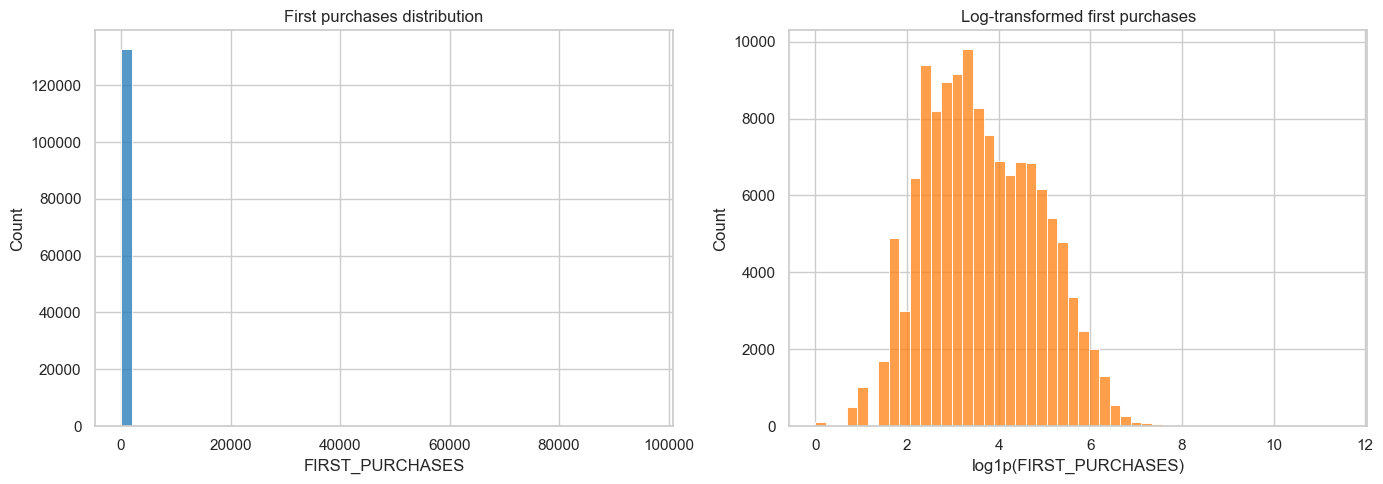

In [12]:
# Create a figure with two side-by-side plots.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Plot the raw distribution of the primary target.
sns.histplot(df_clean[PRIMARY_TARGET], bins=50, ax=axes[0], color="#1f77b4")
# Add a title to the raw target distribution plot.
axes[0].set_title("First purchases distribution")
# Label the x-axis of the raw target distribution plot.
axes[0].set_xlabel(PRIMARY_TARGET)

# Plot the log-transformed distribution of the primary target.
sns.histplot(np.log1p(df_clean[PRIMARY_TARGET]), bins=50, ax=axes[1], color="#ff7f0e")
# Add a title to the transformed target distribution plot.
axes[1].set_title("Log-transformed first purchases")
# Label the x-axis of the transformed target distribution plot.
axes[1].set_xlabel(f"log1p({PRIMARY_TARGET})")

# Adjust the layout so labels do not overlap.
plt.tight_layout()

### Figure interpretation

- The raw `FIRST_PURCHASES` distribution is extremely right-skewed: most days are at low values, with a small number of very large spikes.
- After `log1p` transformation, the target becomes much more compact and closer to a bell-shaped distribution, which reduces outlier dominance.
- Modelling implication: evaluating models on the log scale (or using robust error metrics) is more stable than fitting only on raw-scale values.
- Business implication: occasional campaign/event peaks exist, so average daily performance should be interpreted separately from spike days.


## 7. Time-based exploratory analysis

In [13]:
# Aggregate the main variables to a daily level across all observations.
daily_agg = (
    # Group rows by date and keep the selected columns.
    df_clean.groupby(DATE_COLUMN)[[PRIMARY_TARGET, SECONDARY_TARGET, "total_paid_spend", "total_non_paid_clicks"]]
    # Sum each selected variable for each day.
    .sum()
    # Turn the grouped date index back into a regular column.
    .reset_index()
)
# Preview the daily aggregated table.
daily_agg.head()

,DATE_DAY,FIRST_PURCHASES,ALL_PURCHASES,total_paid_spend,total_non_paid_clicks
0,2019-07-21,18,19,86.95,11.00
1,2019-07-22,25,25,87.50,31.00
2,2019-07-23,19,19,86.00,10.00
3,2019-07-24,21,22,95.61,30.00
4,2019-07-25,31,31,205.92,98.00


### Table interpretation

- The first days show low-to-moderate purchases and relatively small paid/non-paid activity at the start of the timeline.
- `ALL_PURCHASES` is close to `FIRST_PURCHASES` in these rows, suggesting limited repeat-purchase gap early on.
- This table is a daily aggregated view used to inspect trend behaviour before formal modelling.


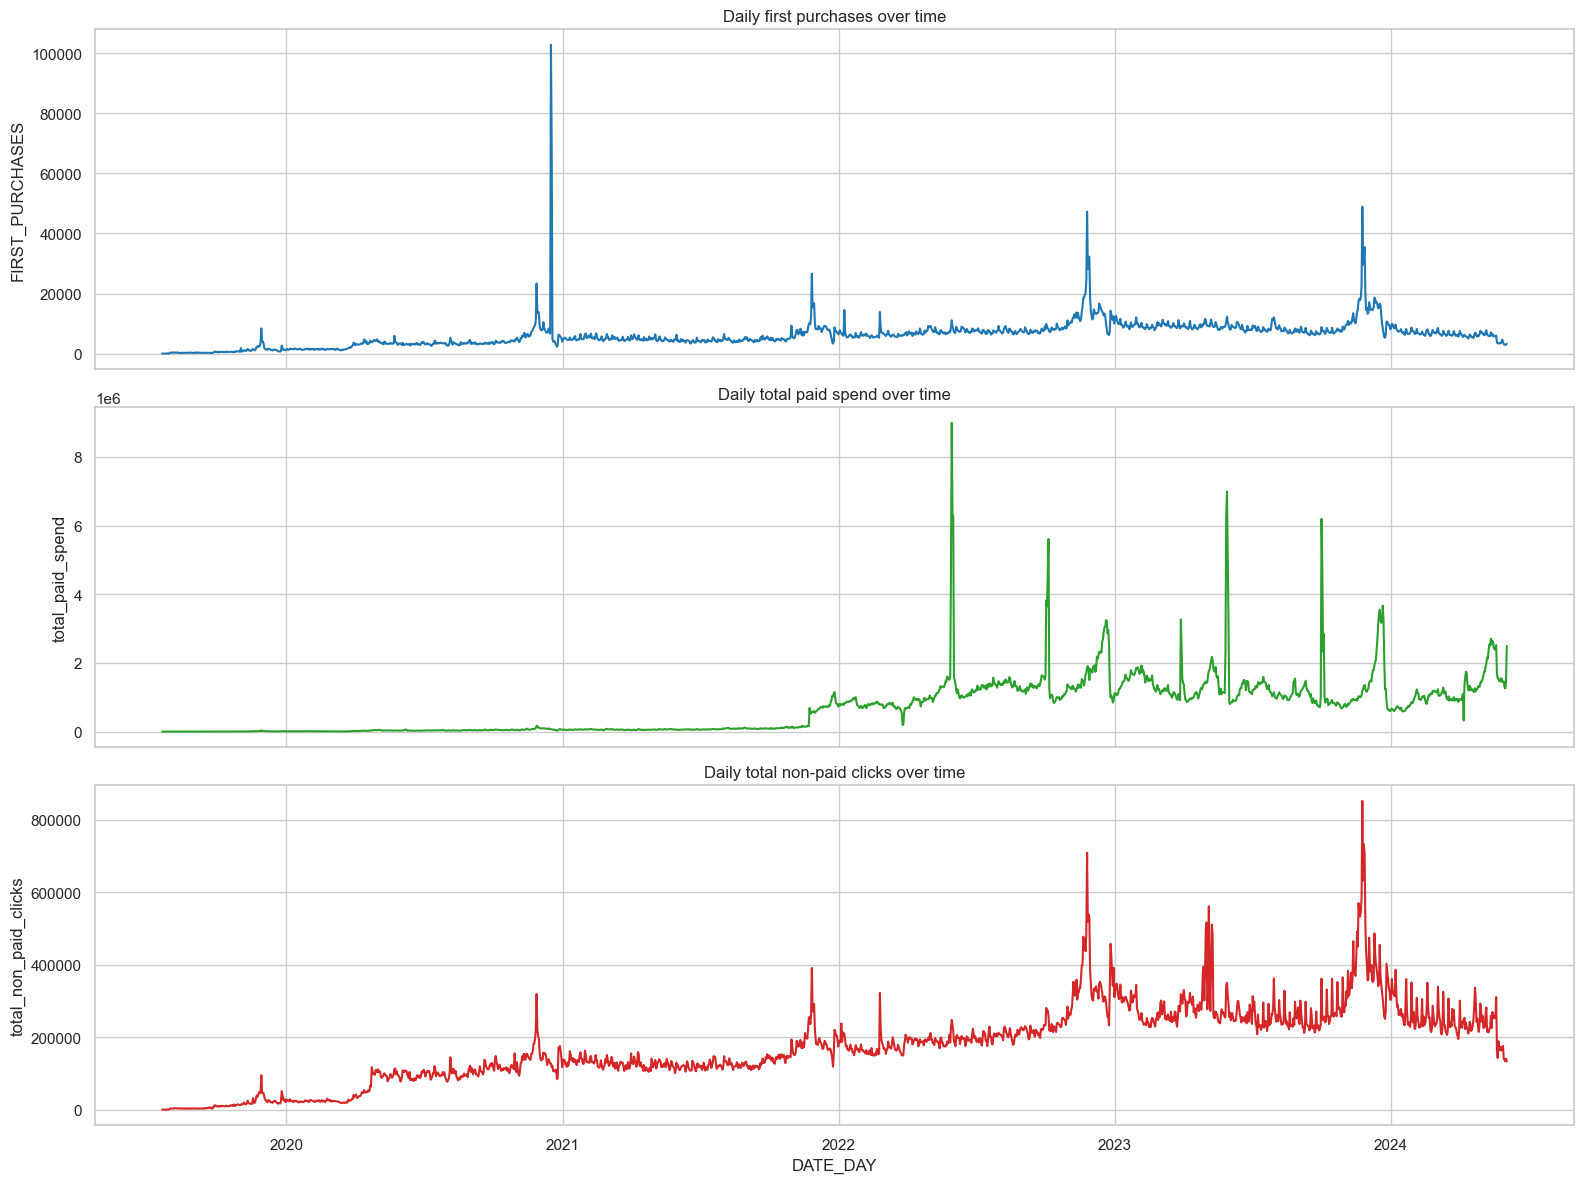

In [14]:
# Create three vertically stacked line charts sharing the same x-axis.
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

# Plot daily first purchases over time.
sns.lineplot(data=daily_agg, x=DATE_COLUMN, y=PRIMARY_TARGET, ax=axes[0], color="#1f77b4")
# Add a title to the first line chart.
axes[0].set_title("Daily first purchases over time")

# Plot total paid spend over time.
sns.lineplot(data=daily_agg, x=DATE_COLUMN, y="total_paid_spend", ax=axes[1], color="#2ca02c")
# Add a title to the second line chart.
axes[1].set_title("Daily total paid spend over time")

# Plot total non-paid clicks over time.
sns.lineplot(data=daily_agg, x=DATE_COLUMN, y="total_non_paid_clicks", ax=axes[2], color="#d62728")
# Add a title to the third line chart.
axes[2].set_title("Daily total non-paid clicks over time")

# Adjust the layout so the subplots fit cleanly.
plt.tight_layout()

### What this figure tells us

1. **All series have strong time dynamics**  
`FIRST_PURCHASES`, paid spend, and non-paid clicks are not stable; they trend and spike over time. This should be treated as a time-series problem rather than random i.i.d. data.

2. **There are major spikes/outliers (campaign/event periods)**  
Sharp peaks appear in all three panels. These are likely promotions, events, or other shocks that can dominate model training if not handled carefully.

3. **Demand and marketing activity move together, but not perfectly**  
When paid spend and non-paid clicks increase, first purchases often increase too, but the relationship is noisy and can be lagged. This supports using time-aware features and chronological validation.


## 8. Relationship analysis

In [15]:
# Define the columns to include in the correlation analysis.
corr_cols = [
    # Include the primary target variable.
    PRIMARY_TARGET,
    # Include the secondary target variable.
    SECONDARY_TARGET,
    # Include the engineered total paid spend feature.
    "total_paid_spend",
    # Include the engineered total paid clicks feature.
    "total_paid_clicks",
    # Include the engineered total paid impressions feature.
    "total_paid_impressions",
    # Include the engineered total non-paid clicks feature.
    "total_non_paid_clicks",
]
# Compute the correlation matrix for the selected columns.
corr_matrix = df_clean[corr_cols].corr()
# Display the correlation matrix.
corr_matrix

,FIRST_PURCHASES,ALL_PURCHASES,total_paid_spend,total_paid_clicks,total_paid_impressions,total_non_paid_clicks
FIRST_PURCHASES,1.00,0.95,0.02,0.27,0.25,0.26
ALL_PURCHASES,0.95,1.00,0.01,0.10,0.08,0.09
total_paid_spend,0.02,0.01,1.00,0.20,0.27,0.15
total_paid_clicks,0.27,0.10,0.20,1.00,0.80,0.90
total_paid_impressions,0.25,0.08,0.27,0.80,1.00,0.57
total_non_paid_clicks,0.26,0.09,0.15,0.90,0.57,1.00


### Table interpretation

- Correlation values show the targets move positively with aggregated paid and non-paid activity.
- `FIRST_PURCHASES` and `ALL_PURCHASES` are strongly aligned in direction.
- These are association signals only and should be validated with time-aware models.


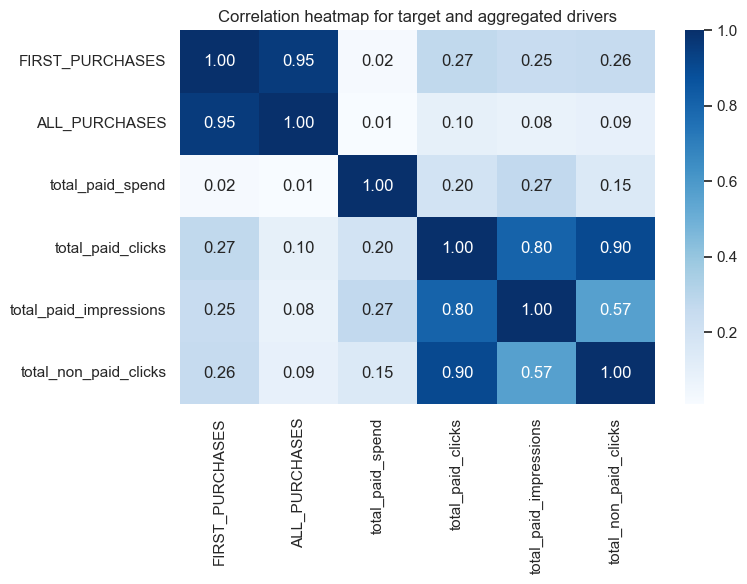

In [16]:
# Create a new figure for the correlation heatmap.
plt.figure(figsize=(8, 6))
# Draw the correlation matrix with annotations.
sns.heatmap(corr_matrix, annot=True, cmap="Blues", fmt=".2f")
# Add a title to the heatmap.
plt.title("Correlation heatmap for target and aggregated drivers")
# Adjust the layout so nothing is clipped.
plt.tight_layout()

### Figure interpretation

- `FIRST_PURCHASES` and `ALL_PURCHASES` are very strongly correlated (`0.95`), so both targets move closely together.
- Correlation between `FIRST_PURCHASES` and `total_paid_spend` is near zero (`0.02`), while correlations with click/impression activity are only modest (`~0.25–0.27`), suggesting spend alone is not linearly explaining daily target variation.
- `total_paid_clicks` is highly correlated with `total_non_paid_clicks` (`0.90`) and strongly correlated with `total_paid_impressions` (`0.80`), indicating multicollinearity among exposure variables.
- Modelling implication: use regularised models and time-aware features (lags/rolling/adstock-style effects) rather than relying on simple same-day linear spend relationships.


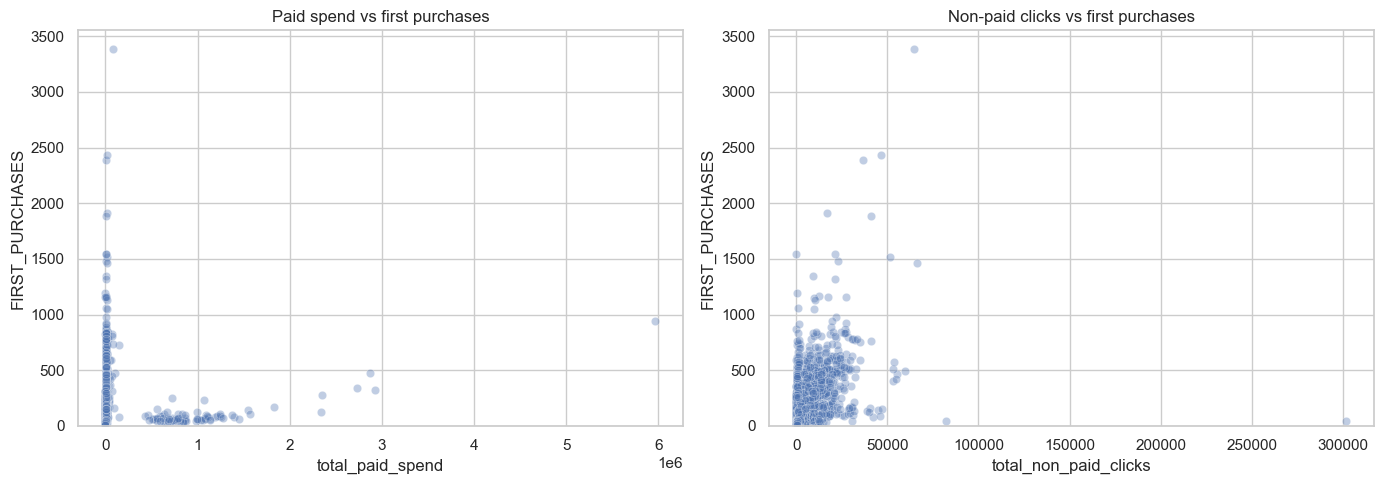

In [17]:
# Take a random sample to keep the scatter plots readable and efficient.
sample_df = df_clean.sample(min(10000, len(df_clean)), random_state=42)

# Create two side-by-side scatter plots.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Plot total paid spend against the primary target.
sns.scatterplot(data=sample_df, x="total_paid_spend", y=PRIMARY_TARGET, alpha=0.35, ax=axes[0])
# Add a title to the first scatter plot.
axes[0].set_title("Paid spend vs first purchases")

# Plot total non-paid clicks against the primary target.
sns.scatterplot(data=sample_df, x="total_non_paid_clicks", y=PRIMARY_TARGET, alpha=0.35, ax=axes[1])
# Add a title to the second scatter plot.
axes[1].set_title("Non-paid clicks vs first purchases")

# Loop through both axes objects.
for ax in axes:
    # Force the y-axis lower bound to start at zero.
    ax.set_ylim(bottom=0)

# Adjust the layout so both plots are displayed cleanly.
plt.tight_layout()

### Figure interpretation

- In both panels, most observations are concentrated at low spend/click levels with low-to-mid `FIRST_PURCHASES`, while a few points sit far from the main cloud.
- The paid-spend plot shows strong dispersion and several high-spend outliers with relatively modest purchases, which suggests weak same-day linear efficiency in parts of the range.
- The non-paid-clicks plot shows a clearer upward tendency than paid spend, but variability is still large, so clicks alone do not reliably explain day-level purchase volume.
- Modelling implication: apply robust validation and consider transformed/lagged features (instead of simple raw linear terms) to reduce outlier influence and capture delayed effects.


## 9. Segment-level EDA

In [18]:
# Aggregate total first purchases by organisation vertical.
top_verticals = (
    # Group the data by organisation vertical and select the primary target.
    df_clean.groupby("ORGANISATION_VERTICAL")[PRIMARY_TARGET]
    # Sum first purchases within each vertical.
    .sum()
    # Sort the totals from highest to lowest.
    .sort_values(ascending=False)
    # Keep only the top 10 verticals.
    .head(10)
)
# Display the top verticals summary.
top_verticals

ORGANISATION_VERTICAL
Business & Industrial    2679103
Apparel                  2314091
Beauty & Fitness         2160968
Home & Garden            1199133
Food & Drink              828322
Toys & Hobbies            352596
Health                    307039
Sports                    264168
Arts & Entertainment      136596
Consumer Electronics       36332
Name: FIRST_PURCHASES, dtype: int64

### Table interpretation

- A few verticals contribute most first purchases, indicating strong category concentration.
- Lower-ranked verticals contribute much less, so segment heterogeneity is substantial.
- Segment controls are likely important for fair and stable modelling.


C:\Users\cindy\AppData\Local\Temp\ipykernel_4660\2791508243.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_verticals.values, y=top_verticals.index, palette="viridis")


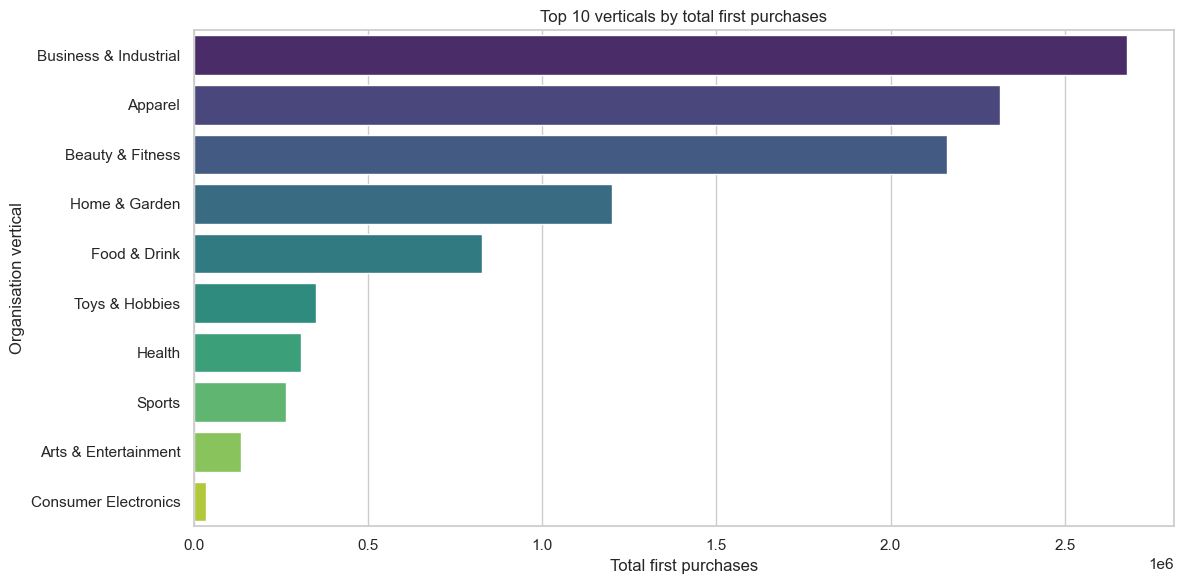

In [19]:
# Create a new figure for the vertical comparison plot.
plt.figure(figsize=(12, 6))
# Draw a horizontal bar chart for the top vertical totals.
sns.barplot(x=top_verticals.values, y=top_verticals.index, palette="viridis")
# Add a title to the bar chart.
plt.title("Top 10 verticals by total first purchases")
# Label the x-axis.
plt.xlabel("Total first purchases")
# Label the y-axis.
plt.ylabel("Organisation vertical")
# Adjust the layout so all labels are visible.
plt.tight_layout()

### Figure interpretation

- `Business & Industrial` is the highest-contributing vertical, followed by `Apparel` and `Beauty & Fitness`; these three dominate total first purchases in the top-10 view.
- There is a clear drop after the top group (`Home & Garden` and below), and the bottom verticals contribute much smaller volumes, showing a long-tail pattern.
- This distribution means purchase behaviour is not uniform across verticals, so modelling should include vertical-level features (or separate segment analysis) to reduce bias from category mix effects.


In [20]:
# Aggregate the target and paid spend by territory.
top_territories = (
    # Group the data by territory and keep the selected columns.
    df_clean.groupby("TERRITORY_NAME")[[PRIMARY_TARGET, "total_paid_spend"]]
    # Sum the selected values within each territory.
    .sum()
    # Sort territories by the primary target in descending order.
    .sort_values(PRIMARY_TARGET, ascending=False)
    # Keep only the top 10 territories.
    .head(10)
)
# Display the top territories summary table.
top_territories

,FIRST_PURCHASES,total_paid_spend
TERRITORY_NAME,,
All Territories,8278503,"1,140,754,784.17"
UK,1156502,"20,085,656.15"
US,836537,"23,437,114.08"
Australia,270782,"3,456,717.81"
Germany,196828,"4,053,887.21"
Canada,86443,"1,788,945.27"
Denmark,66876,"7,059,014.24"
Spain,56000,"495,606.97"
France,53457,"588,464.72"


### Table interpretation

- Territory totals differ materially for both purchases and spend.
- `All Territories` dominates absolute totals, so country-level behaviour can be masked in aggregate views.
- Interpretation should account for cross-currency differences across territories.


## 10. Time-series continuity checks

In [21]:
# Summarise the date range and row count for each time series.
series_lengths = (
    # Group the data by time-series ID and focus on the date column.
    df_clean.groupby("MMM_TIMESERIES_ID")[DATE_COLUMN]
    # Calculate the first date, last date, and number of observations.
    .agg(["min", "max", "count"])
    # Sort from the longest series to the shortest.
    .sort_values("count", ascending=False)
)
# Display the first few time-series summaries.
series_lengths.head()

,min,max,count
MMM_TIMESERIES_ID,,,
cb74696614e226f145f3bf4e0533b100,2019-08-16,2024-05-31,1751
79d11f29f8848fc8589385ace51d7a98,2019-09-27,2024-06-02,1711
07a680d6fd5e932a9507529ee1240d88,2019-09-27,2024-06-02,1711
68361a5fd117219059f3e21001030d43,2019-09-27,2024-06-02,1711
340ad8117bd4a0d0fbdc2ff4acf8a933,2019-10-03,2024-06-02,1705


### Table interpretation

- Observation counts vary across time-series IDs, so data depth is uneven.
- Longer series provide stronger temporal signal for lag/rolling features.
- Very short series may reduce forecast reliability and may need separate handling.


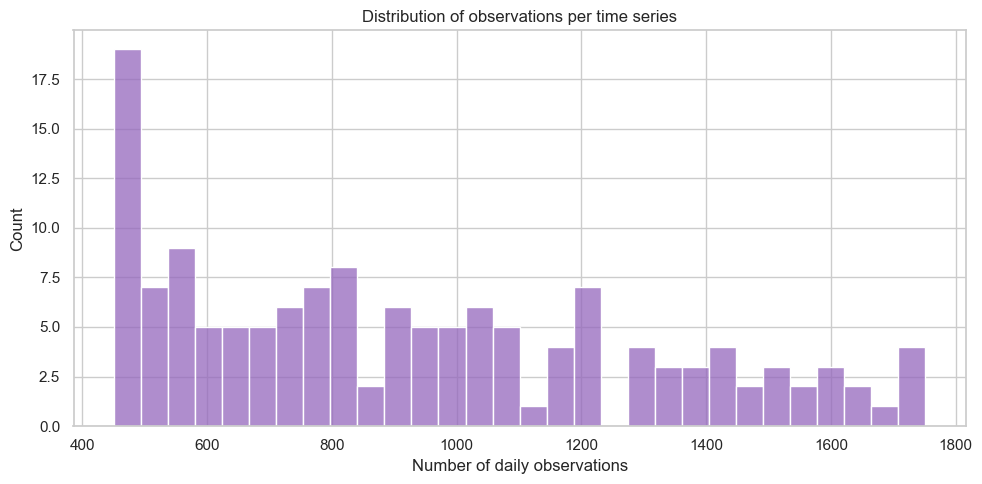

In [22]:
# Create a figure for the time-series length distribution.
plt.figure(figsize=(10, 5))
# Plot the distribution of observation counts across time series.
sns.histplot(series_lengths["count"], bins=30, color="#9467bd")
# Add a title to the histogram.
plt.title("Distribution of observations per time series")
# Label the x-axis.
plt.xlabel("Number of daily observations")
# Adjust the layout to avoid clipping.
plt.tight_layout()

### Figure interpretation

- The number of daily observations varies widely across time-series IDs (roughly from the mid-400s to around 1,700+ days), so panel depth is highly unbalanced.
- There is a visible concentration of shorter-to-mid length series and fewer very long histories, which means model evidence quality differs across IDs.
- Shorter series are more sensitive to noise and give weaker estimates for lag/seasonal effects, while longer series are more suitable for stable forecasting.
- Modelling implication: apply minimum-history filters and use time-aware validation, or model selected long-enough series separately to improve reliability.


## 11. Leakage and modelling risk review

In [23]:
# Create a table listing key modelling risks discovered during EDA.
risk_table = pd.DataFrame(
    {
        # Define the list of risks.
        "risk": [
            # Random splits can leak future information into training.
            "time leakage from random train-test split",
            # Discount variables may only be known after a purchase happens.
            "post-outcome discount variables",
            # Missing media values may represent inactive channels rather than bad data.
            "structural missingness in media channels",
            # The target distribution is skewed and contains extreme values.
            "right-skewed target and extreme outliers",
            # Behaviour may differ substantially across brands and territories.
            "heterogeneity across organisations and territories",
        ],
        # Define the implication of each risk for modelling decisions.
        "implication": [
            # Use time-aware validation to preserve chronology.
            "use chronological splits and preferably grouped validation",
            # Exclude leakage-prone discount variables from the main model.
            "exclude gross discount variables from main feature set",
            # Document the assumption when filling inactive channels with zero.
            "fill inactive media with zero but document the assumption",
            # Compare raw-target and transformed-target approaches.
            "compare raw-target and log-target approaches",
            # Consider adding controls or series-level features.
            "consider segment controls or per-series features",
        ],
    }
)
# Display the modelling risk table.
risk_table

,risk,implication
0,time leakage from random train-test split,use chronological splits and preferably groupe...
1,post-outcome discount variables,exclude gross discount variables from main fea...
2,structural missingness in media channels,fill inactive media with zero but document the...
3,right-skewed target and extreme outliers,compare raw-target and log-target approaches
4,heterogeneity across organisations and territo...,consider segment controls or per-series features


### Table interpretation

- The table summarises the concrete modelling risks found in EDA.
- Each risk has a direct modelling implication (split strategy, feature exclusion, assumptions).
- This forms a defensible rationale for your downstream modelling design.


### Part 11 results summary

1. **Time leakage risk confirmed**: random train/test splitting would leak future information, so chronological splitting is required.
2. **Leakage-prone variables identified**: discount fields (`FIRST_PURCHASES_GROSS_DISCOUNT`, `ALL_PURCHASES_GROSS_DISCOUNT`) should be excluded from the main model.
3. **Structural missingness confirmed**: many media-channel nulls likely represent inactive channels; zero-filling is acceptable if documented.
4. **Target distribution risk confirmed**: strong right-skew and outliers suggest using robust metrics and testing log-target formulations.
5. **Heterogeneity confirmed**: organisations and territories behave differently, so segment controls or per-series features should be considered.


## 12. Save cleaned working dataset

In [24]:
# Define the output path for the cleaned dataset.
output_path = Path("../dataset/conjura_mmm_data_cleaned.parquet")
# Ensure the output folder exists.
output_path.parent.mkdir(parents=True, exist_ok=True)
# Save the cleaned DataFrame as a parquet file without the index.
df_clean.to_parquet(output_path, index=False)
# Print the full resolved save path.
print(f"Saved cleaned dataset to: {output_path.resolve()}")

Saved cleaned dataset to: C:\Users\cindy\Documents\Cindy\UCL Modules\Term 2 Modules\Predictive Analytics\Individual Assignment\dataset\conjura_mmm_data_cleaned.parquet


## 13. Key findings

- The dataset is a panel of brand-territory time series rather than standard tabular observations.
- `FIRST_PURCHASES` is a reasonable primary target for acquisition modelling, but it is highly skewed.
- Media features contain substantial structural missingness, so channel nulls should usually be treated as inactivity.
- Discount variables appear potentially leakage-prone and should be excluded from the main predictive setup unless justified.
- Chronological validation is essential because both the target and predictors are time-dependent.

This notebook prepares the project for the next step: feature engineering and baseline modelling.